In [28]:
import json
import csv
import io

# load the JSON file
with open("data/results.json", "r") as f:
    data = json.load(f)

# add each response to new csv file
with open("data/full-raw-output.csv", "w", newline="") as f:
    writer = csv.writer(f)
    # participant number (arbitrary)
    id = 0
    
    for entry in data:
        raw = entry["content"]
        reader = csv.reader(io.StringIO(raw))
        rows = list(reader)
        # add headers at top
        if id == 0:
            headers = rows[0]
            headers.append('id')
            writer.writerow(headers)
        # add practice trial
        writer.writerow(rows[4] + [id])
        # add other trials
        for row in rows[6:]:
            writer.writerow(row + [id])
        
        id += 1

In [29]:
import pandas as pd

# read CSV file into a dataframe
df = pd.read_csv('data/full-raw-output.csv')

# standardize formatting
df['response'] = df['response'].str.lstrip('{"Q0":"').str.rstrip('"}')
df['response'] = df['response'].str.strip().str.lower()

# narrow to actually relevant columns
df = df[['id', 'n1', 'n2', 'relation_type', 'response', 'rt']]

# populate practice words
df.loc[df['relation_type'] == 'practice', 'n1'] = 'FARMING'
df.loc[df['relation_type'] == 'practice', 'n2'] = 'HARVEST'

# DELETE ID 6, 17, 45 (dummy responses)
df = df[(df['id'] != 6) & (df['id'] != 17) & (df['id'] != 45)]

# create column recording the length of the word that was typed
df['response_length'] = df['response'].str.len()

# manually fix typos...
df.at[272, 'response'] = 'storage'
df.at[306, 'response'] = 'vehicle'
df.at[316, 'response'] = 'vehicle'
df.at[320, 'response'] = 'vehicle'
df.at[322, 'response'] = 'vehicle'
df.at[404, 'response'] = 'vehicle'
df.at[473, 'response'] = 'quattro'
df.at[476, 'response'] = 'screen'
df.at[527, 'response'] = 'vehicle'
df.at[535, 'response'] = 'vehicle'
df.at[540, 'response'] = 'vehicle'
df.at[546, 'response'] = 'suitcase'
df.at[625, 'response'] = 'arugula'
df.at[683, 'response'] = 'brief'
df.at[723, 'response'] = 'soccer'
df.at[742, 'response'] = 'briefcase'
df.at[965, 'response'] = 'field'
df.at[1014, 'response'] = 'gymnasium'
df.at[1077, 'response'] = 'words'
df.at[1222, 'response'] = 'briefcase'
df.at[1317, 'response'] = 'money'


# BROKE RULES: 322
# TWO WORDS: 98, 116, 554, 571, 603, 716, 719, 781, 933, 1086, 1098, 1184, 1216, 1291, 1456, 1460, 1462, 1468
# OF INTEREST: ID 36; ROW 1020
# TYPO? 720

# access specific participants
# print(df[df['id'] == 46])

# access specific cross-sections
# print(df[df['relation_type'] == 'sister'])
# print(df[(df['n1'] == 'COMPUTER') & (df['n2'] == 'PRINTER')])

#NOTE: 56 responses total, 25 trials each including practice

In [30]:
print(df[(df['id'] == 0) & (df['relation_type'] == 'sister')])

    id        n1         n2 relation_type    response     rt  response_length
1    0  COMPUTER    PRINTER        sister  technology   4090               10
4    0   BAGGAGE     WALLET        sister      travel   5913                6
7    0      PANT      SHIRT        sister     garment   6173                7
10   0      HOME  APARTMENT        sister       house   3394                5
11   0       CAR      TRUCK        sister       trunk   5529                5
16   0   STADIUM      TOWER        sister       arena  15643                5


In [31]:
print(df[(df['id'] == 0) & (df['relation_type'] == 'synonym')])

    id        n1          n2 relation_type  response    rt  response_length
3    0   STADIUM       ARENA       synonym  baseball  2753                8
5    0       CAR  AUTOMOBILE       synonym     wheel  2970                5
15   0      PANT     TROUSER       synonym       leg  2680                3
18   0  COMPUTER      DEVICE       synonym    laptop  3033                6
21   0      HOME    DWELLING       synonym     house  2263                5
24   0   BAGGAGE     LUGGAGE       synonym    travel  2787                6


In [32]:
print(df[(df['id'] < 6) & (df['relation_type'] == 'practice')])

     id       n1       n2 relation_type response    rt  response_length
0     0  FARMING  HARVEST      practice     corn  3364                4
25    1  FARMING  HARVEST      practice     crop  8817                4
50    2  FARMING  HARVEST      practice     plow  6782                4
75    3  FARMING  HARVEST      practice     food  7929                4
100   4  FARMING  HARVEST      practice    grain  3700                5
125   5  FARMING  HARVEST      practice    grass  3393                5


In [2]:
import numpy as np

def cosine_sim(x: np.ndarray, y: np.ndarray):
    """
    compute cosine similarity between two 1D vectors, x and y
    cosine similarity is the dot product of x and y when they are normalized to unit length.
    """
    return np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y))

def get_dict_from_file(filename):
    """
    generates dictionary from file
    assumes file is in GloVe format of [ word num num num ... ] on each line
    in other words: for each line in file, first element is word and subsequent elements are embeddings
    """
    embedding_dict = {}
    with open(filename, "r") as file:
        # loop through and put stuff in dict
        for line in file:
            # word part is: line.split(maxsplit=1)[0]
            # embedding part is: line.split(maxsplit=1)[1]
            embedding_dict[line.split(maxsplit=1)[0]] = np.fromstring(line.split(maxsplit=1)[1], sep=' ')
    return embedding_dict

# NOTE: assumes glove.300d.txt file in data subfolder!
embedding = get_dict_from_file("data/glove.300d.txt")

In [4]:
# example use of cosine_sim
cosine_sim(embedding["baggage"], embedding["wallet"])

0.3369199546310008

In [5]:
# add column to df for cosine similarity between n1 and n2
df["n_sim"] = [
    cosine_sim(embedding[n1.lower()], embedding[n2.lower()])
    if n1.lower() in embedding and n2.lower() in embedding
    else np.nan
    for n1, n2 in zip(df["n1"], df["n2"])
]

In [406]:
df.to_csv('data/output.csv', index=False)

In [9]:
# simple function to return the average of two input embeddings
def avg_embed(e1, e2):
    return (e1 + e2) / 2

# make a copy of the dataframe
df_sims = df.copy()

# add column for cosine similarity between n1 and response
df_sims["r_n1_sim"] = [
    cosine_sim(embedding[n1.lower()], embedding[response.lower()])
    if n1.lower() in embedding and response.lower() in embedding
    else np.nan
    for n1, response in zip(df_sims["n1"], df_sims["response"])
]

# add column for cosine similarity between response and n2
df_sims["r_n2_sim"] = [
    cosine_sim(embedding[response.lower()], embedding[n2.lower()])
    if response.lower() in embedding and n2.lower() in embedding
    else np.nan
    for response, n2 in zip(df_sims["response"], df_sims["n2"])
]

# add column for average cosine similarity between response and n1 and n2
df_sims["avg_sim"] = df_sims[["r_n1_sim", "r_n2_sim"]].mean(axis=1, skipna=False)

# add column for cosine similarity between response and average embedding of n1 and n2
df_sims["avg_embed_sim"] = [
    cosine_sim(embedding[response], avg_embed(embedding[n1], embedding[n2]))
    if response in embedding and n1 in embedding and n2 in embedding
    else np.nan
    for response, n1, n2 in zip(df_sims["response"].str.lower(), df_sims["n1"].str.lower(), df_sims["n2"].str.lower())
]

# output this dataframe to new csv file
df_sims.to_csv('data/sims.csv', index=False)

In [25]:
import nltk
from nltk.corpus import wordnet as wn
from nltk.corpus import wordnet_ic
semcor_ic = wordnet_ic.ic('ic-semcor.dat')

# dict of dicts, top level each x to vals, inner dict maps words to synsets
lem = {
    "HOME":
    {
    "HOME": "dwelling.n.01", 
    "DWELLING": "dwelling.n.01",
    "BEDROOM": "bedroom.n.01",
    "HOUSING": "housing.n.01",
    "APARTMENT": "apartment.n.01",
    },
    "BAGGAGE" :
    {
    "BAGGAGE": "baggage.n.01",
    "LUGGAGE": "baggage.n.01",
    "HANDLE": "handle.n.01",
    "CASE": "case.n.05",
    "WALLET": "wallet.n.01"
    },
    "COMPUTER":
    {
        "COMPUTER": "computer.n.01",
        "DEVICE": "computer.n.01",
        "KEYBOARD": "keyboard.n.01",
        "MACHINE": "machine.n.01",
        "PRINTER": "printer.n.03"
    },
    "STADIUM":
    {
        "STADIUM" : "stadium.n.01",
        "ARENA" : "stadium.n.01",
        "FIELD": "playing_field.n.02",
        "STRUCTURE": "structure.n.01",
        "TOWER": "tower.n.01",
    },
    "CAR":
    {
        "CAR": "car.n.01",
        "AUTOMOBILE": "car.n.01",
        "TRUNK": "luggage_compartment.n.01",
        "VEHICLE": "motor_vehicle.n.01",
        "TRUCK": "truck.n.01",
    },
    "PANT":
    {
        "PANT": "trouser.n.01",
        "TROUSER": "trouser.n.01",
        "ZIPPER": "slide_fastener.n.01",
        "GARMENT": "garment.n.01",
        "SHIRT": "shirt.n.01",
    }
}

In [26]:
df_extra = df.copy()
df_extra["lin_similarity"] = [
    wn.synset(lem[n1][n1]).lin_similarity(wn.synset(lem[n1][n2]), semcor_ic)
    if n1 in lem and n2 in lem[n1]
    else np.nan 
    for n1, n2 in zip(df_extra["n1"], df_extra["n2"])
]
df_extra.to_csv('data/extra.csv', index=False)

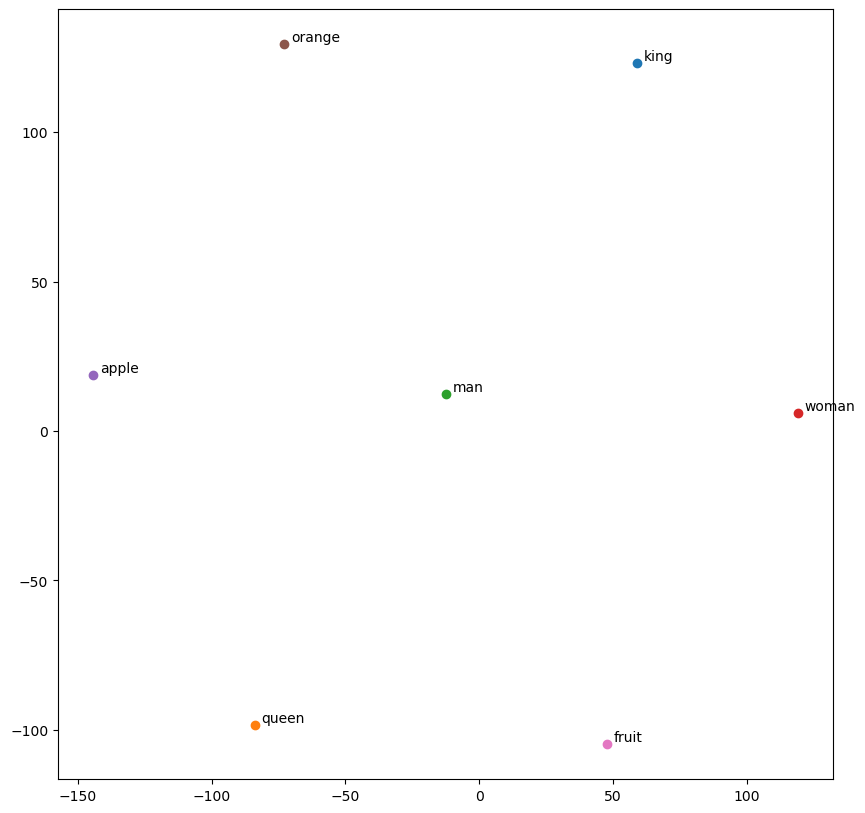

In [5]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def visualize_embeddings(embeddings_dict, words_to_plot):
    # Extract vectors for selected words
    vectors = np.array([embeddings_dict[word] for word in words_to_plot])
    
    # Reduce dimensions to 2D using t-SNE
    tsne = TSNE(n_components=2, random_state=0, perplexity=len(words_to_plot)-1)
    vectors_2d = tsne.fit_transform(vectors)
    
    # Create the scatter plot
    plt.figure(figsize=(10, 10))
    for i, word in enumerate(words_to_plot):
        x, y = vectors_2d[i, :]
        plt.scatter(x, y)
        plt.annotate(word, (x, y), xytext=(5, 2), textcoords="offset points")
    plt.show()

words = ["king", "queen", "man", "woman", "apple", "orange", "fruit"]
visualize_embeddings(embedding, words)